In [ ]:
# Cell 1: Imports
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from TrajectoryNet import dataset
import scanpy as sc
import anndata as ad

In [4]:
# Cell 2: Downloading Code
import urllib.request
import os

os.makedirs('../data', exist_ok=True)

url = "https://github.com/KrishnaswamyLab/TrajectoryNet/raw/master/data/eb_velocity_v5.npz"
print("Downloading EB dataset...")
urllib.request.urlretrieve(url, "../data/eb_velocity_v5.npz")
print("Done!")

Done!


In [5]:
eb_data = dataset.EBData("pcs", max_dim=5)
data = eb_data.data
labels = eb_data.get_times()

print("Cell coordinates shape:", data.shape)
print("Time labels shape:", labels.shape)
print("Unique time points:", np.unique(labels))
print("Cells per time point:")
for t in np.unique(labels):
    print(f"  t={t}: {np.sum(labels == t)} cells")

Cell coordinates shape: (16819, 5)
Time labels shape: (16819,)
Unique time points: [0 1 2 3 4]
Cells per time point:
  t=0: 2381 cells
  t=1: 4163 cells
  t=2: 3278 cells
  t=3: 3665 cells
  t=4: 3332 cells


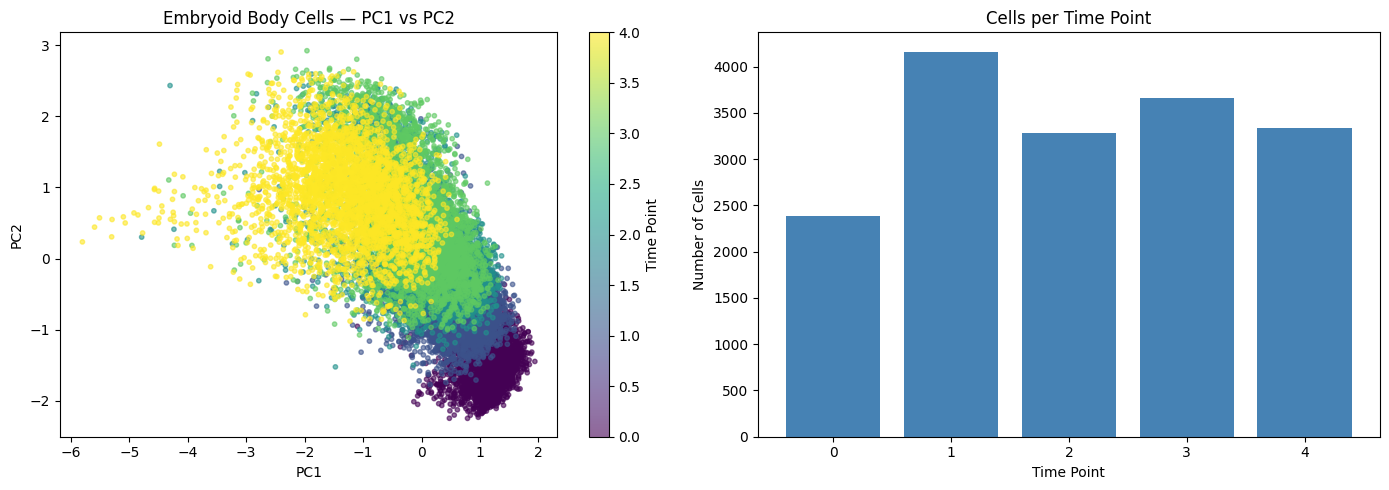

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scatter = axes[0].scatter(data[:, 0], data[:, 1], 
                          c=labels, cmap='viridis', 
                          alpha=0.6, s=10)
plt.colorbar(scatter, ax=axes[0], label='Time Point')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title('Embryoid Body Cells — PC1 vs PC2')

time_counts = [np.sum(labels == t) for t in np.unique(labels)]
axes[1].bar([str(t) for t in np.unique(labels)], time_counts, color='steelblue')
axes[1].set_xlabel('Time Point')
axes[1].set_ylabel('Number of Cells')
axes[1].set_title('Cells per Time Point')

plt.tight_layout()
plt.savefig('../figures/01_data_overview.png', dpi=150)
plt.show()

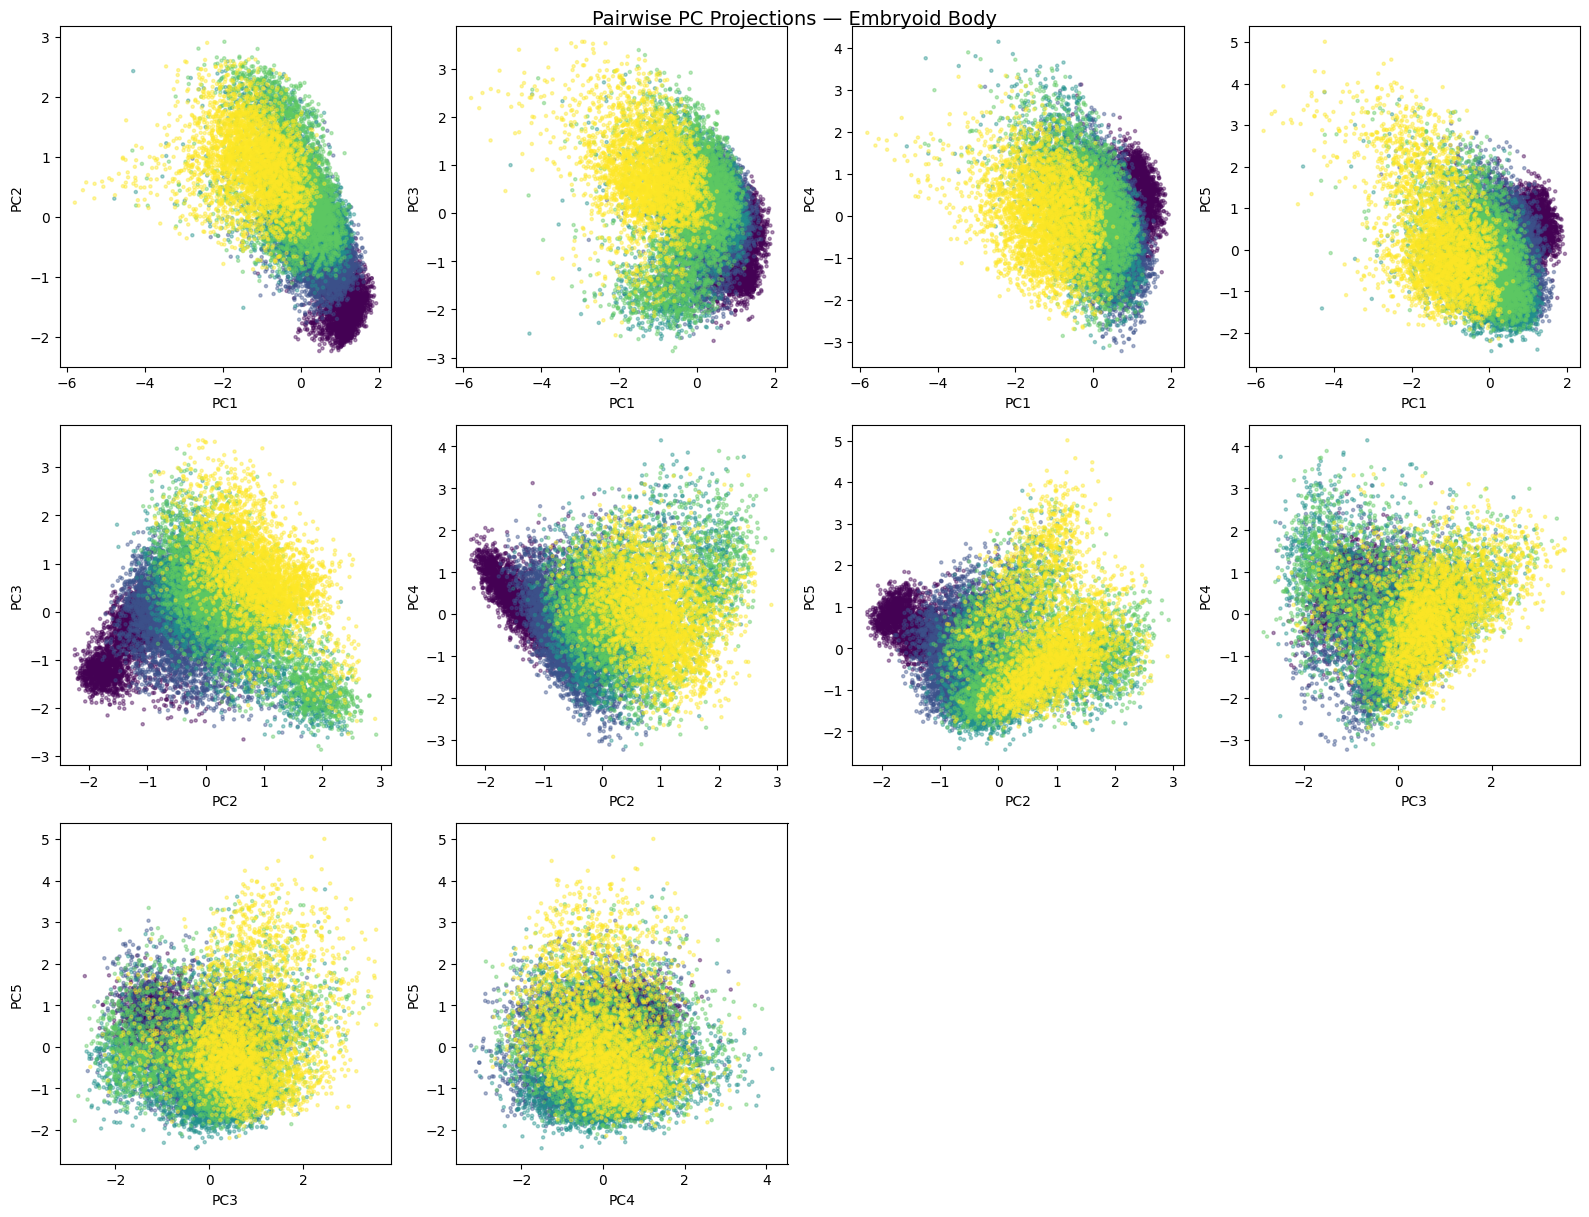

In [7]:
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
pc_pairs = [(i, j) for i in range(5) for j in range(5) if i < j]

for idx, (i, j) in enumerate(pc_pairs):
    ax = axes[idx // 4][idx % 4]
    scatter = ax.scatter(data[:, i], data[:, j],
                        c=labels, cmap='viridis',
                        alpha=0.4, s=5)
    ax.set_xlabel(f'PC{i+1}')
    ax.set_ylabel(f'PC{j+1}')

# hide unused subplots
for idx in range(len(pc_pairs), 16):
    axes[idx // 4][idx % 4].set_visible(False)

plt.suptitle('Pairwise PC Projections — Embryoid Body', fontsize=14)
plt.tight_layout()
plt.savefig('../figures/01_pairwise_pcs.png', dpi=150)
plt.show()